In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import struct
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
# 1. Thiết lập thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [4]:
# 2. Xây dựng lớp Dataset tùy chỉnh
class LocalMNIST(Dataset):
    def __init__(self, image_path, label_path, transform=None):
        self.transform = transform
        self.images = self.read_images(image_path)
        self.labels = self.read_labels(label_path)

    def read_images(self, path):
        with open(path, 'rb') as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.fromfile(f, dtype=np.uint8).reshape(num, 28, 28)
        return images

    def read_labels(self, path):
        with open(path, 'rb') as f:
            magic, num = struct.unpack(">II", f.read(8))
            labels = np.fromfile(f, dtype=np.uint8)
        return labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label

In [5]:
# 3. Chuẩn bị dữ liệu và Augmentation
transform_train = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ElasticTransform(alpha=50.0, sigma=5.0),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_img_path = '/content/drive/MyDrive/MNIST/dataset/handwritten/train-images.idx3-ubyte'
train_lbl_path = '/content/drive/MyDrive/MNIST/dataset/handwritten/train-labels.idx1-ubyte'
test_img_path = '/content/drive/MyDrive/MNIST/dataset/handwritten/t10k-images.idx3-ubyte'
test_lbl_path = '/content/drive/MyDrive/MNIST/dataset/handwritten/t10k-labels.idx1-ubyte'

train_dataset = LocalMNIST(train_img_path, train_lbl_path, transform=transform_train)
test_dataset = LocalMNIST(test_img_path, test_lbl_path, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [6]:
# 4. Định nghĩa mạng ANN
class ANN_MNIST(nn.Module):
    def __init__(self):
        super(ANN_MNIST, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

In [7]:
model = ANN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
# Lưu trữ Metrics
train_losses = []
train_accuracies = []

epochs = 25
print("\nBắt đầu quá trình huấn luyện...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = 100 * correct_train / total_train

    # Lưu lại lịch sử để vẽ biểu đồ
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # In ra kết quả từng epoch
    print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}%")

print("\nHoàn thành huấn luyện!")


Bắt đầu quá trình huấn luyện...
Epoch [01/25] | Train Loss: 0.4757 - Train Acc: 85.13%
Epoch [02/25] | Train Loss: 0.2170 - Train Acc: 93.32%
Epoch [03/25] | Train Loss: 0.1726 - Train Acc: 94.60%
Epoch [04/25] | Train Loss: 0.1559 - Train Acc: 95.15%
Epoch [05/25] | Train Loss: 0.1405 - Train Acc: 95.65%
Epoch [06/25] | Train Loss: 0.1271 - Train Acc: 96.05%
Epoch [07/25] | Train Loss: 0.1207 - Train Acc: 96.14%
Epoch [08/25] | Train Loss: 0.1156 - Train Acc: 96.48%
Epoch [09/25] | Train Loss: 0.1105 - Train Acc: 96.48%
Epoch [10/25] | Train Loss: 0.1094 - Train Acc: 96.57%
Epoch [11/25] | Train Loss: 0.1052 - Train Acc: 96.69%
Epoch [12/25] | Train Loss: 0.1013 - Train Acc: 96.80%
Epoch [13/25] | Train Loss: 0.0993 - Train Acc: 96.82%
Epoch [14/25] | Train Loss: 0.0941 - Train Acc: 97.00%
Epoch [15/25] | Train Loss: 0.0923 - Train Acc: 97.08%
Epoch [16/25] | Train Loss: 0.0889 - Train Acc: 97.15%
Epoch [17/25] | Train Loss: 0.0880 - Train Acc: 97.21%
Epoch [18/25] | Train Loss: 0.08

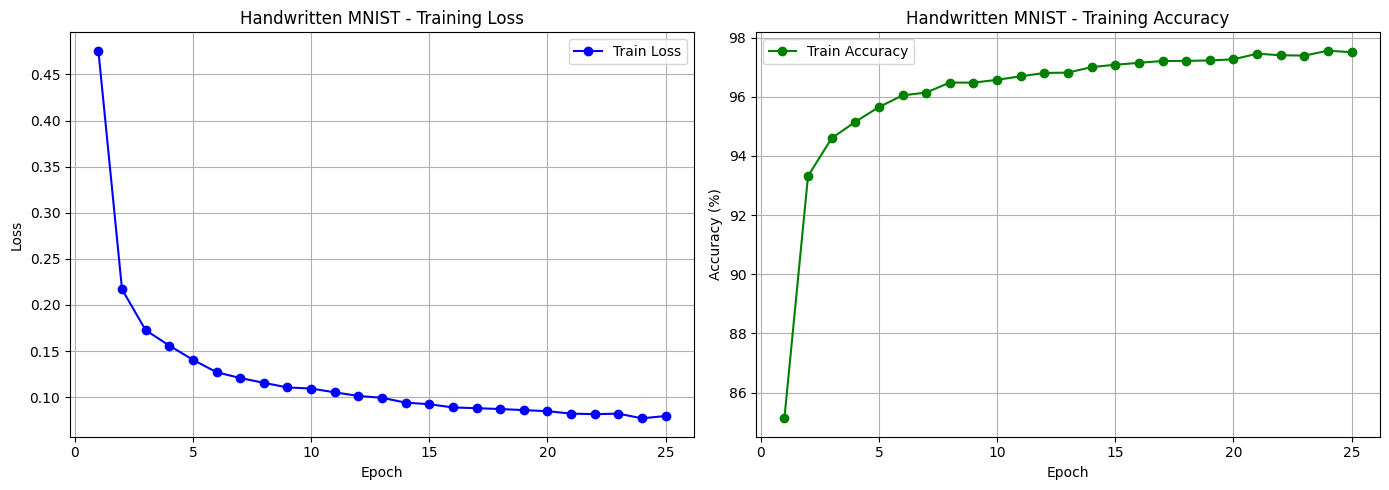

In [11]:
# 6. Visualization
plt.figure(figsize=(14, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', color='blue', marker='o')
plt.title('Handwritten MNIST - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, label='Train Accuracy', color='green', marker='o')
plt.title('Handwritten MNIST - Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# 7. Đánh giá Độc lập trên tập Test
print("\n--- ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
model.eval()
test_running_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

final_loss = test_running_loss / total_test
final_acc = 100 * correct_test / total_test

print(f"Kết quả kiểm thử:")
print(f" > Test Loss: {final_loss:.4f}")
print(f" > Test Accuracy: {final_acc:.2f}%")


--- ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---
Kết quả kiểm thử:
 > Test Loss: 0.0297
 > Test Accuracy: 99.03%
